## Práctica 3-1 | Diamantes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df_diamonds = sns.load_dataset('diamonds')
df_diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


#### Revisar nulos

In [3]:
df_diamonds.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

#### Obtenemos la variable dependiente e independiente. 

In [4]:
x = df_diamonds['carat'].values.reshape(-1, 1)
y = df_diamonds['price'].values.reshape(-1, 1)

#### Lo dividimos en subsets

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.3, random_state=0)

### Implementar el modelo de regresión lineal

In [ ]:
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### predicción

In [13]:
y_pred = regressor.predict(X_train)

### Evaluar el modelo

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

print(f"Coefficients: \n {regressor.coef_}")
print(f"Independent term: \n {regressor.intercept_}")
print("Mean squared error: %.2f" % mean_squared_error(Y_train, y_pred))

Coefficients: 
 [[7741.37904828]]
Independent term: 
 [-2247.70447085]
Mean squared error: 2408781.08


In [16]:
print(regressor.score(X_test, Y_test))
print("Variance score: %.2f" % r2_score(Y_train, y_pred))

0.8509771156910653
Variance score: 0.85


### Graficar los resultados

Text(0.5, 0.98, 'Linear regression model')

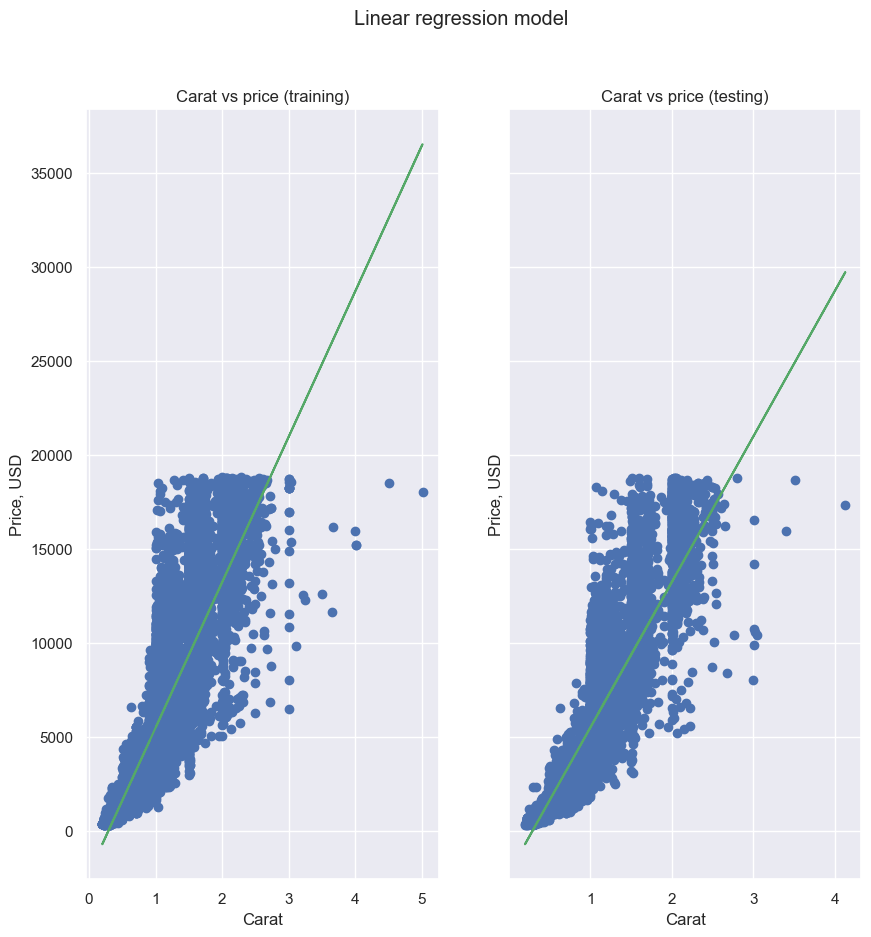

In [17]:
sns.set_theme()
fig, ax = plt.subplots(1, 2, figsize=(10, 10), sharey=True)
ax[0].scatter(X_train, Y_train)
ax[0].plot(X_train, regressor.predict(X_train), c='g')
ax[0].set_title('Carat vs price (training)')
ax[0].set_xlabel('Carat')
ax[0].set_ylabel('Price, USD')
ax[1].scatter(X_test, Y_test)
ax[1].plot(X_test, regressor.predict(X_test), c='g')
ax[1].set_title('Carat vs price (testing)')
ax[1].set_xlabel('Carat')
ax[1].set_ylabel('Price, USD')
plt.suptitle('Linear regression model')

#### Otra variable independiente (z)

In [18]:
xx = df_diamonds[['carat', 'z']].values
yy = df_diamonds['price'].values.reshape(-1, 1)
XX_train, XX_test, YY_train, YY_test = train_test_split(xx, yy, test_size=0.3, random_state=0)
regressor.fit(XX_train, YY_train)
regressor.score(XX_test, YY_test)

0.855295875757326

### Conclusión

El procedimiento que usamos fue, básicamente:
- Separar las variables dependiente e independiente.
- Separar los datos en set de entrenamiento y set de prueba.
- Entrenar el modelo con el set de entrenamiento.
- Validar el modelo con el set de prueba y calcular el score.

De acuerdo a los resultados podemos ver que relación significativa entre el carat y el precio del diamante, esto lo podemos ver porque el coeficiente r2 es aprox. 0.85, esto nos indica un buen nivel de ajuste.
De igual forma agregarmos una segunda variable independiente y se mejora muy ligeramente el ajuste, aunque es poco.